# 04 — Analisis ACF / PACF (CPI Global)

Estimacion visual de los ordenes p, q (ARIMA) y P, Q (SARIMA)
a partir de los correlogramas de la serie diferenciada.

**Reglas Box-Jenkins:**
- ACF decaimiento exponencial + PACF corte en lag k → AR(k)
- ACF corte en lag k + PACF decaimiento → MA(k)
- Picos en lags 12, 24, 36 → ordenes estacionales

**Nota:** si los tests (notebook 02) confirman que la tasa YoY es I(0),
el analisis parte directamente del nivel sin diferenciar.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

NOTEBOOK_DIR = Path("C:/Users/usuario/OneDrive/Documentos/GitHub/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})


In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "cpi_global_monthly.parquet")
train = df.loc[:DATE_TRAIN_END]
y = train["cpi_global_rate"]
y.index.freq = "MS"

y_diff1    = y.diff().dropna()
y_diff12   = y.diff(12).dropna()
y_diff1_12 = y.diff().diff(12).dropna()

print(f"Nivel: {len(y)} obs | diff(1): {len(y_diff1)} | diff(12): {len(y_diff12)} | diff(1,12): {len(y_diff1_12)}")


Nivel: 228 obs | diff(1): 227 | diff(12): 216 | diff(1,12): 215


## 1. ACF / PACF — Serie en nivel (tasa YoY)

Si la tasa YoY es estacionaria (resultado de notebook 02),
aqui vemos directamente los ordenes p, q candidatos.


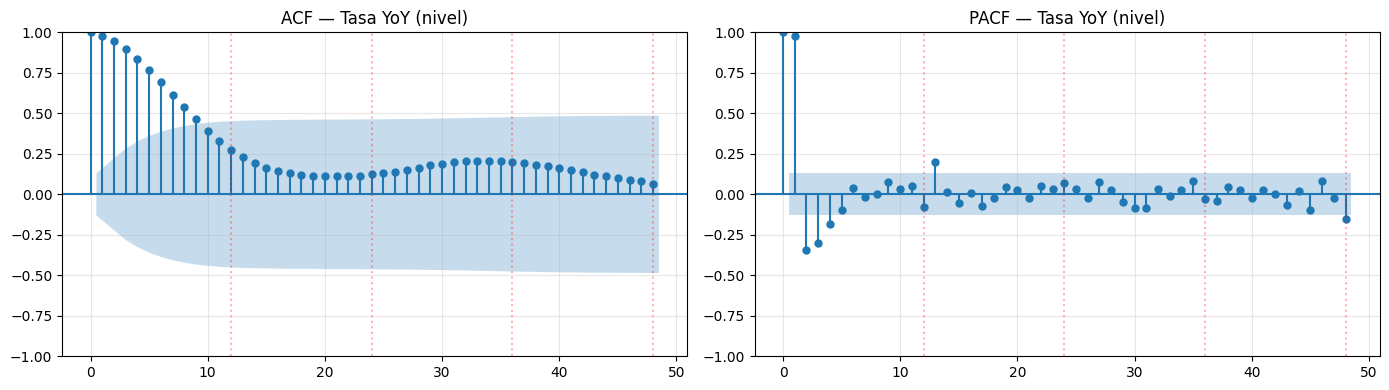

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=48, ax=axes[0], title="ACF — Tasa YoY (nivel)")
plot_pacf(y, lags=48, ax=axes[1], title="PACF — Tasa YoY (nivel)", method="ywm")
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


## 2. ACF / PACF — Primera diferencia (d=1)

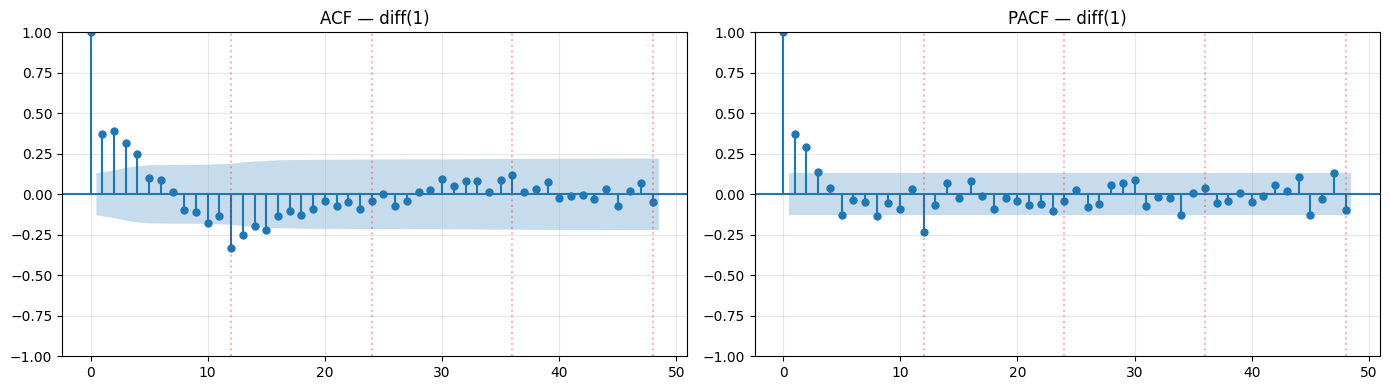

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff1, lags=48, ax=axes[0], title="ACF — diff(1)")
plot_pacf(y_diff1, lags=48, ax=axes[1], title="PACF — diff(1)", method="ywm")
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


## 3. ACF / PACF — Diferencia estacional (D=1, lag 12)

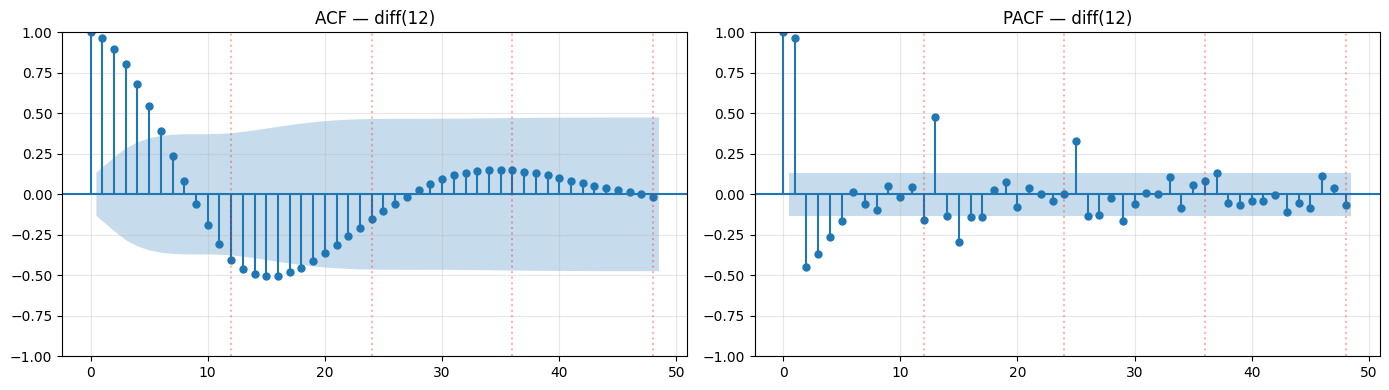

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff12, lags=48, ax=axes[0], title="ACF — diff(12)")
plot_pacf(y_diff12, lags=48, ax=axes[1], title="PACF — diff(12)", method="ywm")
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. ACF / PACF — Doble diferencia (d=1, D=1)

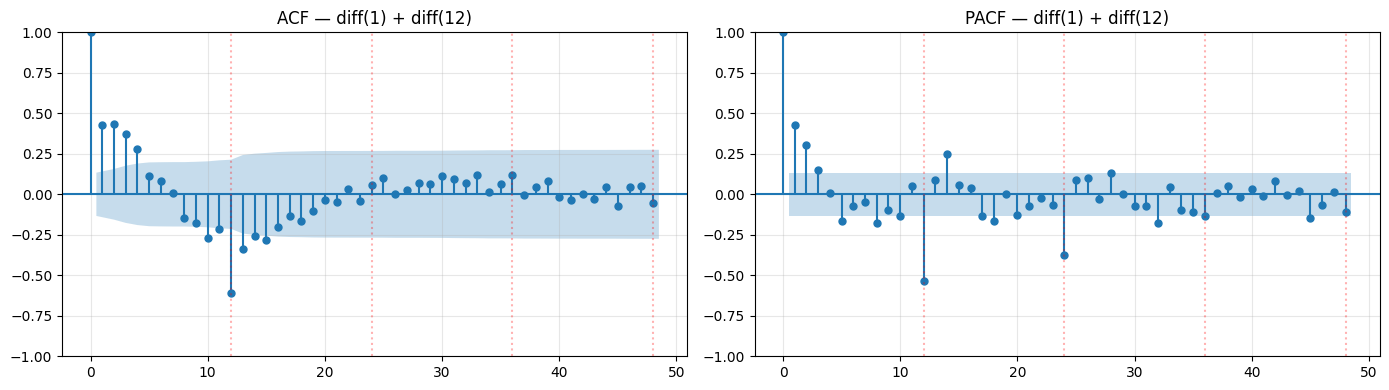

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff1_12, lags=48, ax=axes[0], title="ACF — diff(1) + diff(12)")
plot_pacf(y_diff1_12, lags=48, ax=axes[1], title="PACF — diff(1) + diff(12)", method="ywm")
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Valores numericos en lags clave

In [7]:
# Tests de estacionariedad (notebook 02): ADF p=0.010, PP p=0.145, KPSS rechaza
# -> resultado borderline pero consenso hacia I(1): usamos y_diff1
# Tests estacionalidad (notebook 03): Fs=-0.08 -> D=0, sin componente estacional
series_for_model = y_diff1
series_name      = "diff(1)"

lags_key = [1, 2, 3, 6, 12, 24, 36]
n  = len(series_for_model)
ci = 1.96 / np.sqrt(n)

acf_vals  = acf(series_for_model, nlags=max(lags_key))
pacf_vals = pacf(series_for_model, nlags=max(lags_key), method="ywm")

print(f"Serie: {series_name}  |  n={n}  |  IC 95%: +/- {ci:.4f}")
print(f"{'Lag':>4} {'ACF':>10} {'PACF':>10} {'ACF sig':>10} {'PACF sig':>10}")
print("-" * 50)
for lag in lags_key:
    a, p = acf_vals[lag], pacf_vals[lag]
    print(f"{lag:4d} {a:10.4f} {p:10.4f} {'*' if abs(a) > ci else '':>10} {'*' if abs(p) > ci else '':>10}")

Serie: diff(1)  |  n=227  |  IC 95%: +/- 0.1301
 Lag        ACF       PACF    ACF sig   PACF sig
--------------------------------------------------
   1     0.3696     0.3696          *          *
   2     0.3883     0.2915          *          *
   3     0.3173     0.1366          *          *
   6     0.0872    -0.0381                      
  12    -0.3329    -0.2344          *          *
  24    -0.0434    -0.0407                      
  36     0.1168     0.0395                      


## 6. Estimacion de ordenes candidatos

In [8]:
max_lag_regular  = 6
max_lag_seasonal = 3   # multiplos de 12

acf_full  = acf(series_for_model, nlags=36)
pacf_full = pacf(series_for_model, nlags=36, method="ywm")

acf_sig_regular  = [i for i in range(1, max_lag_regular + 1) if abs(acf_full[i])  > ci]
pacf_sig_regular = [i for i in range(1, max_lag_regular + 1) if abs(pacf_full[i]) > ci]
seasonal_lags    = [12 * i for i in range(1, max_lag_seasonal + 1)]
acf_sig_seasonal  = [i for i in seasonal_lags if abs(acf_full[i])  > ci]
pacf_sig_seasonal = [i for i in seasonal_lags if abs(pacf_full[i]) > ci]

print("=" * 60)
print(f"LAGS SIGNIFICATIVOS en serie: {series_name}")
print("=" * 60)
print(f"ACF  regular  (1-{max_lag_regular}): {acf_sig_regular}")
print(f"PACF regular  (1-{max_lag_regular}): {pacf_sig_regular}")
print(f"ACF  estacional:  {acf_sig_seasonal}")
print(f"PACF estacional:  {pacf_sig_seasonal}")

print()
print("=" * 60)
print("ORDENES CANDIDATOS para ARIMA (d=1, D=0)")
print("=" * 60)
print("d = 1  (ADF p=0.010, PP p=0.145, KPSS rechaza estacionariedad en nivel)")
print("D = 0  (Fs=-0.08, sin estacionalidad significativa — mediana global cancela patrones)")
print(f"p candidatos: {pacf_sig_regular or [0, 1, 2]}")
print(f"q candidatos: {acf_sig_regular  or [0, 1, 2]}")
print("P = 0, Q = 0  (D=0 -> no se necesitan terminos estacionales)")
print()
print("Estos candidatos guian auto_arima(d=1, D=0, seasonal=False) en pmdarima.")

LAGS SIGNIFICATIVOS en serie: diff(1)
ACF  regular  (1-6): [1, 2, 3, 4]
PACF regular  (1-6): [1, 2, 3]
ACF  estacional:  [12]
PACF estacional:  [12]

ORDENES CANDIDATOS para ARIMA (d=1, D=0)
d = 1  (ADF p=0.010, PP p=0.145, KPSS rechaza estacionariedad en nivel)
D = 0  (Fs=-0.08, sin estacionalidad significativa — mediana global cancela patrones)
p candidatos: [1, 2, 3]
q candidatos: [1, 2, 3, 4]
P = 0, Q = 0  (D=0 -> no se necesitan terminos estacionales)

Estos candidatos guian auto_arima(d=1, D=0, seasonal=False) en pmdarima.


## 7. Ljung-Box

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(series_for_model, lags=[6, 12, 24], return_df=True)
print(f"Test Ljung-Box sobre '{series_name}' (H0: no autocorrelacion hasta lag k):")
print(lb)
print()
print("Si p < 0.05: autocorrelacion significativa -> confirma que el modelo debe capturarla.")


Test Ljung-Box sobre 'diff(1)' (H0: no autocorrelacion hasta lag k):
       lb_stat     lb_pvalue
6   108.132832  5.013497e-21
12  152.151968  2.073882e-26
24  206.235264  6.464407e-31

Si p < 0.05: autocorrelacion significativa -> confirma que el modelo debe capturarla.


## 8. Conclusion

**Resumen de ordenes para ARIMA — CPI Global:**

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| d | **1** | ADF p=0.010 (marginal), PP p=0.145 rechaza, KPSS rechaza estac. en nivel |
| D | **0** | Fs = -0.079: sin estacionalidad (mediana global cancela patrones nacionales) |
| m | N/A | D=0 -> no aplica diferenciacion estacional |
| p | TBD | PACF de diff(1): ver celdas 12-14 |
| q | TBD | ACF de diff(1): ver celdas 12-14 |
| P | 0 | D=0 |
| Q | 0 | D=0 |

**Diferencia clave con Espana:**
- Espana: SARIMA(p,1,q)(P,1,Q)12 — estacionalidad fuerte en indice nivel
- Global: ARIMA(p,1,q) sin componente estacional — la agregacion de 186 paises cancela la estacionalidad

*Los valores p, q se extraen de los lags significativos de ACF/PACF sobre diff(1) (celdas 12-14).*